In [2]:
import pandas as pd

In [4]:
detailed_attributes = pd.read_csv("detailed_attributes.csv")
detailed_attributes.head()

,StyleCode,FrameConstruction,FrameShape,RXAble,Gender,SunOptical,Material1,Material2,USRetailPrice,USWholesalePrice
0,CK19119,Full Rim,Square,True,Female,Optical,Acetate,Acetate,223.0,111.5
1,CK19569,Full Rim,Round,True,Unisex,Optical,Acetate,Acetate,295.0,147.5
2,CK19573,Full Rim,Rectangle,True,Male,Optical,Acetate,Acetate,180.0,90.0
3,CK20527,Full Rim,Square,True,Female,Optical,Acetate,Acetate,158.0,79.0
4,CK20531,Full Rim,Rectangle,True,Male,Optical,Acetate,Acetate,126.0,63.0


In [9]:
demand= pd.read_csv('final_demand.csv')
demand["StyleCode"]

0       CK20541S
1       CK20541S
2       CK20541S
3       CK20541S
4       CK20541S
          ...   
1459       L995S
1460       L995S
1461       L995S
1462       L995S
1463       L995S
Name: StyleCode, Length: 1464, dtype: object

In [ ]:
detailed_attributes["StyleCode"] = detailed_attributes["StyleCode"].astype(str).str.strip()
demand["StyleCode"] = demand["StyleCode"].astype(str).str.strip()

merged_df = demand.merge(detailed_attributes, on="StyleCode", how="left")
merged_df.head()

Top 10 StyleCodes by units sold:


,UnitsSold
StyleCode,
L2707,27275.0
L2876,21559.0
NIKE 5038,19126.0
L2707N,18389.0
NIKE 5538,18361.0
NIKE 7125,17455.0
L2271,16553.0
NIKE 7246,15892.0
NIKE 5019,15741.0


Most popular material:


,UnitsSold
Material,
Bio Inj-G820,476416.0
Acetate,313352.0
Metal,155163.0
Titanium,49260.0


Most popular style category (FrameShape):


...

Quarterly summary:


,Quarter,Quantity,SalesValue
0,2023Q3,74106.0,14717669.0
1,2023Q4,205904.0,41018925.0
2,2024Q1,285692.0,57117362.0
3,2024Q2,273238.0,53336453.0
4,2024Q3,155251.0,30563470.8


Seasonal summary:


,Season,Quantity,SalesValue
3,Winter,238711.0,48024497.45
1,Spring,290108.0,56933637.80
2,Summer,241467.0,47394089.85
0,Fall,223905.0,44401654.70


Peak month by quantity: 03/2024 (103086 units)
Peak month by sales value: 03/2024 ($20,427,804)
Peak season by quantity: Spring (290108 units)
Peak season by sales value: Spring ($56,933,638)
Note: SalesValue is in USD (actual dollars), not in millions.


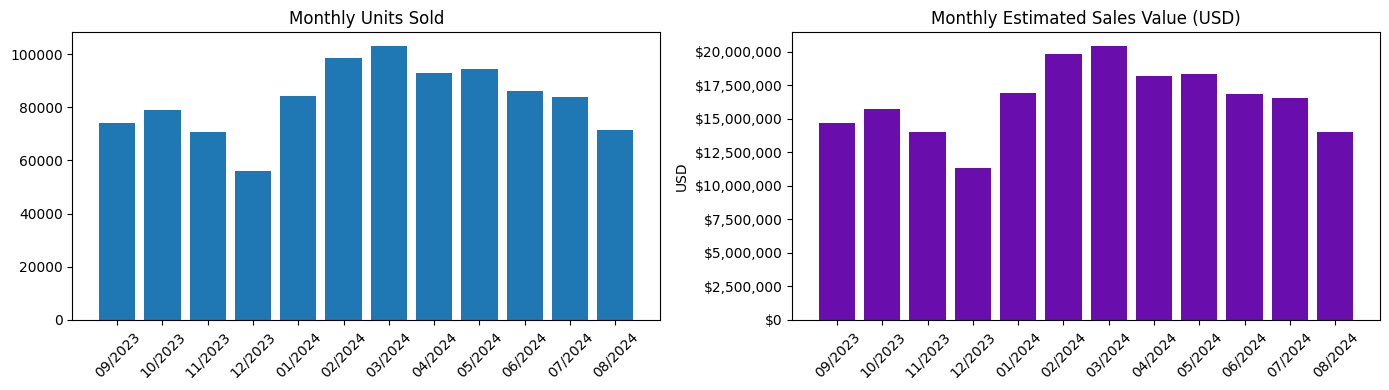

In [14]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Monthly quantity columns in the dataset
month_cols = sorted(
    [c for c in merged_df.columns if "/" in c and len(c) == 7],
    key=lambda x: pd.to_datetime(x, format="%m/%Y")
)

# Use consistent columns for material/style/price after the merge
material_col = "Material1_x" if "Material1_x" in merged_df.columns else "Material1"
style_col = "FrameShape_x" if "FrameShape_x" in merged_df.columns else "FrameShape"
price_col = "USRetailPrice_x" if "USRetailPrice_x" in merged_df.columns else "USRetailPrice"

merged_df["Material"] = merged_df[material_col]
if "Material1_y" in merged_df.columns:
    merged_df["Material"] = merged_df["Material"].fillna(merged_df["Material1_y"])
merged_df["Material"] = merged_df["Material"].where(merged_df["Material"].notna(), "Unknown").astype(str).str.strip().str.title()

merged_df["StyleCategory"] = merged_df[style_col]
if "FrameShape_y" in merged_df.columns:
    merged_df["StyleCategory"] = merged_df["StyleCategory"].fillna(merged_df["FrameShape_y"])
merged_df["StyleCategory"] = merged_df["StyleCategory"].where(merged_df["StyleCategory"].notna(), "Unknown").astype(str).str.strip().str.title()

merged_df["Total"] = pd.to_numeric(merged_df["Total"], errors="coerce").fillna(0)

# Top sellers by quantity across all available months
top_stylecode = (
    merged_df.groupby("StyleCode", dropna=False)["Total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .to_frame("UnitsSold")
)

top_material = (
    merged_df.groupby("Material", dropna=False)["Total"]
    .sum()
    .sort_values(ascending=False)
    .to_frame("UnitsSold")
)

top_style_category = (
    merged_df.groupby("StyleCategory", dropna=False)["Total"]
    .sum()
    .sort_values(ascending=False)
    .to_frame("UnitsSold")
)

top_brand = (
    merged_df.groupby("Brand", dropna=False)["Total"]
    .sum()
    .sort_values(ascending=False)
    .to_frame("UnitsSold")
)

print("Top 10 StyleCodes by units sold:")
display(top_stylecode)

print("Most popular material:")
display(top_material.head(10))

print("Most popular style category (FrameShape):")
display(top_style_category)

print("Most popular brand:")
display(top_brand)

# Month-level quantity and estimated sales value (quantity * retail price)
month_long = merged_df.melt(
    id_vars=[price_col],
    value_vars=month_cols,
    var_name="Month",
    value_name="Quantity"
)
month_long["Quantity"] = pd.to_numeric(month_long["Quantity"], errors="coerce").fillna(0)
month_long["Price"] = pd.to_numeric(month_long[price_col], errors="coerce").fillna(0)
month_long["SalesValue"] = month_long["Quantity"] * month_long["Price"]

month_summary = (
    month_long.groupby("Month", as_index=False)
    .agg(Quantity=("Quantity", "sum"), SalesValue=("SalesValue", "sum"))
)
month_summary["MonthDate"] = pd.to_datetime(month_summary["Month"], format="%m/%Y")
month_summary = month_summary.sort_values("MonthDate")
month_summary["Quarter"] = month_summary["MonthDate"].dt.to_period("Q").astype(str)

season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall"
}
month_summary["Season"] = month_summary["MonthDate"].dt.month.map(season_map)

quarter_summary = month_summary.groupby("Quarter", as_index=False)[["Quantity", "SalesValue"]].sum()
season_summary = month_summary.groupby("Season", as_index=False)[["Quantity", "SalesValue"]].sum()
season_order = ["Winter", "Spring", "Summer", "Fall"]
season_summary["Season"] = pd.Categorical(season_summary["Season"], categories=season_order, ordered=True)
season_summary = season_summary.sort_values("Season")

print("Monthly sales summary (units vs estimated sales value):")
display(month_summary[["Month", "Quantity", "SalesValue"]])

print("Quarterly summary:")
display(quarter_summary)

print("Seasonal summary:")
display(season_summary)

best_month_qty = month_summary.loc[month_summary["Quantity"].idxmax(), ["Month", "Quantity"]]
best_month_value = month_summary.loc[month_summary["SalesValue"].idxmax(), ["Month", "SalesValue"]]
best_season_qty = season_summary.loc[season_summary["Quantity"].idxmax(), ["Season", "Quantity"]]
best_season_value = season_summary.loc[season_summary["SalesValue"].idxmax(), ["Season", "SalesValue"]]

print(f"Peak month by quantity: {best_month_qty['Month']} ({best_month_qty['Quantity']:.0f} units)")
print(f"Peak month by sales value: {best_month_value['Month']} (${best_month_value['SalesValue']:,.0f})")
print(f"Peak season by quantity: {best_season_qty['Season']} ({best_season_qty['Quantity']:.0f} units)")
print(f"Peak season by sales value: {best_season_value['Season']} (${best_season_value['SalesValue']:,.0f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(month_summary["Month"], month_summary["Quantity"], color="#1f77b4")
axes[0].set_title("Monthly Units Sold")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(month_summary["Month"], month_summary["SalesValue"], color="#6a0dad")
axes[1].set_title("Monthly Estimated Sales Value (USD)")
axes[1].set_ylabel("USD")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].tick_params(axis="x", rotation=45)

print("Note: SalesValue is in USD (actual dollars), not in millions.")

plt.tight_layout()
plt.show()

In [ ]:
# Top brand in each month and label it on monthly bars
month_cols = sorted(
    [c for c in merged_df.columns if "/" in c and len(c) == 7],
    key=lambda x: pd.to_datetime(x, format="%m/%Y")
)

brand_month_long = merged_df.melt(
    id_vars=["Brand"],
    value_vars=month_cols,
    var_name="Month",
    value_name="Quantity"
)
brand_month_long["Quantity"] = pd.to_numeric(brand_month_long["Quantity"], errors="coerce").fillna(0)

brand_month = (
    brand_month_long.groupby(["Month", "Brand"], as_index=False)["Quantity"]
    .sum()
)
top_idx = brand_month.groupby("Month")["Quantity"].idxmax()
top_brand_by_month = brand_month.loc[top_idx].copy()
top_brand_by_month = top_brand_by_month.rename(columns={"Brand": "TopBrand", "Quantity": "TopBrandQty"})
top_brand_by_month["MonthDate"] = pd.to_datetime(top_brand_by_month["Month"], format="%m/%Y")
top_brand_by_month = top_brand_by_month.sort_values("MonthDate")

monthly_total = (
    brand_month_long.groupby("Month", as_index=False)["Quantity"]
    .sum()
    .rename(columns={"Quantity": "TotalQty"})
)
monthly_total["MonthDate"] = pd.to_datetime(monthly_total["Month"], format="%m/%Y")
monthly_total = monthly_total.sort_values("MonthDate")

top_brand_by_month = monthly_total.merge(
    top_brand_by_month[["Month", "TopBrand", "TopBrandQty"]],
    on="Month",
    how="left"
)
top_brand_by_month["TopBrandSharePct"] = (top_brand_by_month["TopBrandQty"] / top_brand_by_month["TotalQty"]) * 100

print("Top brand by month:")
display(top_brand_by_month[["Month", "TopBrand", "TopBrandQty", "TotalQty", "TopBrandSharePct"]])

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top_brand_by_month["Month"], top_brand_by_month["TotalQty"], color="#1f77b4")
ax.set_title("Monthly Quantity with Top Brand Label")
ax.set_ylabel("Units Sold")
ax.tick_params(axis="x", rotation=45)

for bar, brand in zip(bars, top_brand_by_month["TopBrand"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(brand),
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=8
    )

plt.tight_layout()
plt.show()

,Brand,EstimatedSalesUSD,SharePct
4,NIKE OPTICAL,95908241.0,48.745286
2,LACOSTE OPTICAL,46598859.8,23.683833
0,CALVIN KLEIN OPTICAL,24283790.0,12.342217
5,NIKE SUN,15916980.0,8.089792
3,LACOSTE SUNS,10488650.0,5.330848
1,CALVIN KLEIN SUN,3557359.0,1.808025


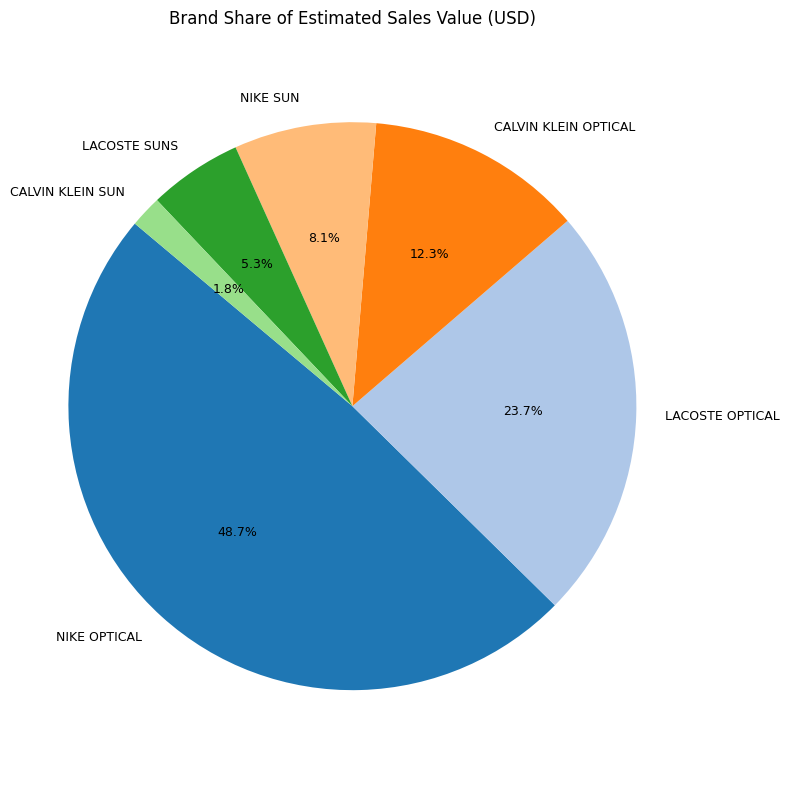

In [16]:
# Pie chart: brand share of estimated sales value (USD)
price_col = "USRetailPrice_x" if "USRetailPrice_x" in merged_df.columns else "USRetailPrice"

brand_sales = merged_df[["Brand", "Total", price_col]].copy()
brand_sales["Total"] = pd.to_numeric(brand_sales["Total"], errors="coerce").fillna(0)
brand_sales["Price"] = pd.to_numeric(brand_sales[price_col], errors="coerce").fillna(0)
brand_sales["EstimatedSalesUSD"] = brand_sales["Total"] * brand_sales["Price"]

brand_share = (
    brand_sales.groupby("Brand", as_index=False)["EstimatedSalesUSD"]
    .sum()
    .sort_values("EstimatedSalesUSD", ascending=False)
)
brand_share["SharePct"] = (brand_share["EstimatedSalesUSD"] / brand_share["EstimatedSalesUSD"].sum()) * 100

display(brand_share)

fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.tab20.colors[: len(brand_share)]
ax.pie(
    brand_share["EstimatedSalesUSD"],
    labels=brand_share["Brand"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    textprops={"fontsize": 9}
)
ax.set_title("Brand Share of Estimated Sales Value (USD)")
ax.axis("equal")
plt.tight_layout()
plt.show()

Region share of estimated sales value (USD):


,Region,EstimatedSalesUSD,SharePct
0,AMER,1.124486e+08,57.151935
1,EMEA,8.430523e+07,42.848065


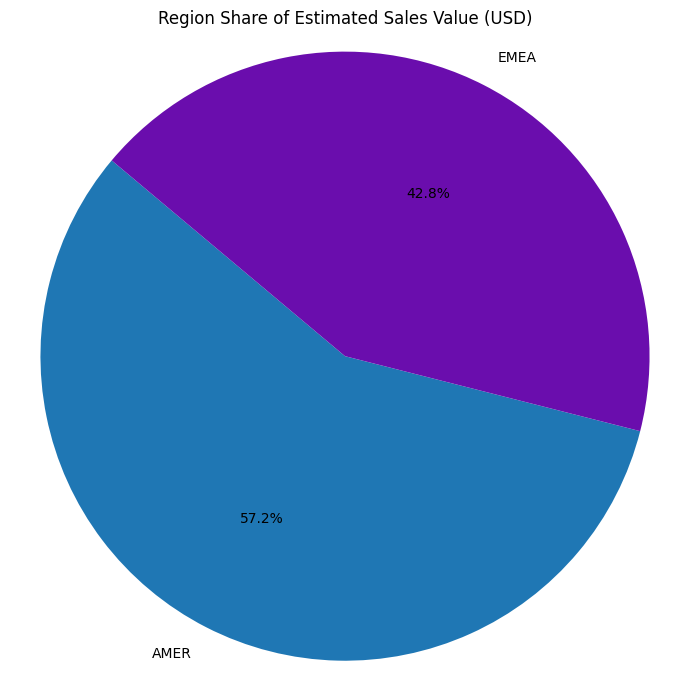

In [17]:
# Pie chart: region share of estimated sales value (USD)
region_col = "Macro Region|Orig. Req. Deliv. Month/Year"
price_col = "USRetailPrice_x" if "USRetailPrice_x" in merged_df.columns else "USRetailPrice"

region_sales = merged_df[[region_col, "Total", price_col]].copy()
region_sales[region_col] = region_sales[region_col].fillna("Unknown").astype(str).str.strip()
region_sales["Total"] = pd.to_numeric(region_sales["Total"], errors="coerce").fillna(0)
region_sales["Price"] = pd.to_numeric(region_sales[price_col], errors="coerce").fillna(0)
region_sales["EstimatedSalesUSD"] = region_sales["Total"] * region_sales["Price"]

region_share = (
    region_sales.groupby(region_col, as_index=False)["EstimatedSalesUSD"]
    .sum()
    .sort_values("EstimatedSalesUSD", ascending=False)
)
region_share["SharePct"] = (region_share["EstimatedSalesUSD"] / region_share["EstimatedSalesUSD"].sum()) * 100
region_share = region_share.rename(columns={region_col: "Region"})

print("Region share of estimated sales value (USD):")
display(region_share)

fig, ax = plt.subplots(figsize=(7, 7))
colors = ["#1f77b4", "#6a0dad", "#2ca02c", "#d62728", "#17becf"]
ax.pie(
    region_share["EstimatedSalesUSD"],
    labels=region_share["Region"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors[:len(region_share)],
    textprops={"fontsize": 10}
)
ax.set_title("Region Share of Estimated Sales Value (USD)")
ax.axis("equal")
plt.tight_layout()
plt.show()

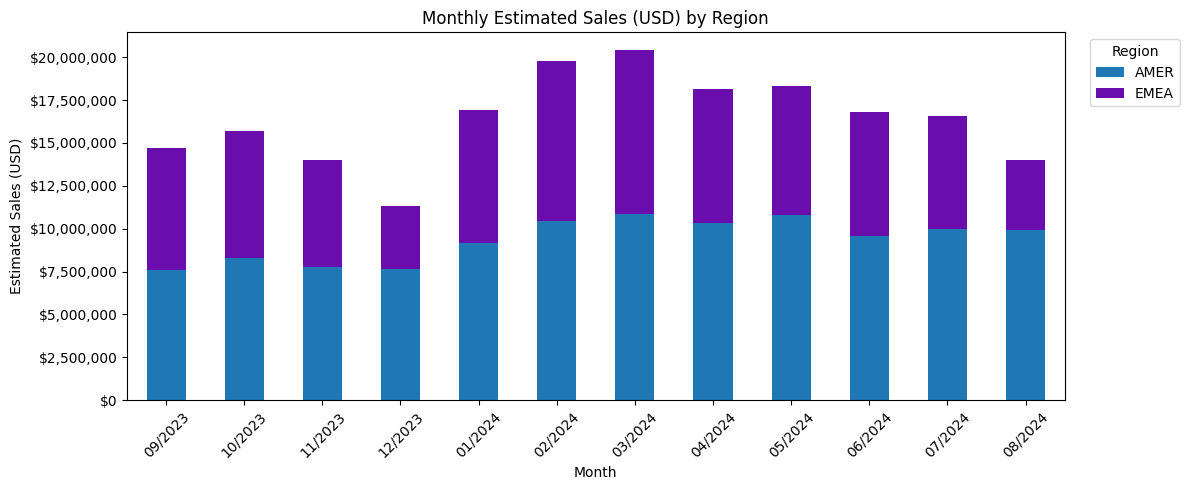

In [18]:
# Monthly estimated sales bar chart segmented by region
from matplotlib.ticker import FuncFormatter

region_col = "Macro Region|Orig. Req. Deliv. Month/Year"
price_col = "USRetailPrice_x" if "USRetailPrice_x" in merged_df.columns else "USRetailPrice"
month_cols = sorted(
    [c for c in merged_df.columns if "/" in c and len(c) == 7],
    key=lambda x: pd.to_datetime(x, format="%m/%Y")
)

monthly_region_long = merged_df.melt(
    id_vars=[region_col, price_col],
    value_vars=month_cols,
    var_name="Month",
    value_name="Quantity"
)
monthly_region_long["Region"] = monthly_region_long[region_col].fillna("Unknown").astype(str).str.strip()
monthly_region_long["Quantity"] = pd.to_numeric(monthly_region_long["Quantity"], errors="coerce").fillna(0)
monthly_region_long["Price"] = pd.to_numeric(monthly_region_long[price_col], errors="coerce").fillna(0)
monthly_region_long["SalesValueUSD"] = monthly_region_long["Quantity"] * monthly_region_long["Price"]

monthly_region = (
    monthly_region_long.groupby(["Month", "Region"], as_index=False)["SalesValueUSD"]
    .sum()
)
monthly_region_pivot = monthly_region.pivot(index="Month", columns="Region", values="SalesValueUSD").fillna(0)
monthly_region_pivot = monthly_region_pivot.reindex(month_cols)

ax = monthly_region_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    color=["#1f77b4", "#6a0dad", "#2ca02c", "#d62728", "#17becf"]
)
ax.set_title("Monthly Estimated Sales (USD) by Region")
ax.set_xlabel("Month")
ax.set_ylabel("Estimated Sales (USD)")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [19]:
# Top-selling model (StyleCode) in AMER and EMEA
region_col = "Macro Region|Orig. Req. Deliv. Month/Year"

merged_df["Total"] = pd.to_numeric(merged_df["Total"], errors="coerce").fillna(0)
region_model_sales = (
    merged_df.assign(Region=merged_df[region_col].fillna("Unknown").astype(str).str.strip())
    .groupby(["Region", "StyleCode"], as_index=False)["Total"]
    .sum()
    .rename(columns={"Total": "UnitsSold"})
)

target_regions = ["AMER", "EMEA"]
region_model_sales = region_model_sales[region_model_sales["Region"].isin(target_regions)]

top_model_each_region = (
    region_model_sales.sort_values(["Region", "UnitsSold"], ascending=[True, False])
    .groupby("Region", as_index=False)
    .head(1)
)

print("Top-selling model in each region:")
display(top_model_each_region)

print("Top 10 models in AMER:")
display(
    region_model_sales[region_model_sales["Region"] == "AMER"]
    .sort_values("UnitsSold", ascending=False)
    .head(10)
)

print("Top 10 models in EMEA:")
display(
    region_model_sales[region_model_sales["Region"] == "EMEA"]
    .sort_values("UnitsSold", ascending=False)
    .head(10)
)

Top-selling model in each region:


,Region,StyleCode,UnitsSold
126,AMER,NIKE 7125,14219.0
258,EMEA,L2707,20417.0


Top 10 models in AMER:


,Region,StyleCode,UnitsSold
126,AMER,NIKE 7125,14219.0
143,AMER,NIKE 7246,14096.0
148,AMER,NIKE 8045,13048.0
153,AMER,NIKE 8154,11767.0
121,AMER,NIKE 7090,11583.0
111,AMER,NIKE 5538,11129.0
92,AMER,NIKE 4307,10776.0
118,AMER,NIKE 7057,10342.0
150,AMER,NIKE 8130,9798.0
131,AMER,NIKE 7160,9754.0


Top 10 models in EMEA:


,Region,StyleCode,UnitsSold
258,EMEA,L2707,20417.0
261,EMEA,L2876,14317.0
259,EMEA,L2707N,13443.0
253,EMEA,L2271,12086.0
274,EMEA,L6010MAG-SET,10114.0
254,EMEA,L2291,9867.0
300,EMEA,NIKE 5038,9563.0
257,EMEA,L2692,8203.0
266,EMEA,L3632,8044.0
267,EMEA,L3647,8005.0
